# Evaluierung & Analyse des Metrik-Gewichtungs-Experiments auf dem Lebenshilfe-Datensatz
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert und vergleicht das **Encoder-Decoder-Übersetzungsmodell (`facebook/mbart-large-50`)** unter systematisch variierten Gewichtungen der Verbund-Reward-Funktion (*Composite Reward*) im Direct Preference Optimization (DPO) Training:

$$R(x, y) = w_{\text{style}} \cdot R_{\text{style}}(y) + w_{\text{sem}} \cdot R_{\text{sem}}(x, y)$$

### Untersuchte Modellkonfigurationen:
1. **SFT Baseline:** Supervised Fine-Tuning Referenzmodell (`results/models/sft`)
2. **DPO `w05_w05`:** Ausgewogenes Modell mit $w_{\text{style}}=0.5, w_{\text{sem}}=0.5$ (`results/models/metric_weights_exp/dpo_w05_w05`)
3. **DPO `w07_w03`:** Priorisierte Vereinfachung mit $w_{\text{style}}=0.7, w_{\text{sem}}=0.3$ (`results/models/metric_weights_exp/dpo_w07_w03`)
4. **DPO `w10_w00`:** Maximale Simplicity ohne Semantik-Führung $w_{\text{style}}=1.0, w_{\text{sem}}=0.0$ (`results/models/metric_weights_exp/dpo_w10_w00`)

### Forschungsfragen:
- **F1 (Simplicity Gain):** Steigt der gemessene Simplicity-Score ($R_{\text{style}}$) kontinuierlich mit wachsendem $w_{\text{style}}$?
- **F2 (Information Loss & Truncation):** Ab welchem Gewichtungspunkt bricht der semantische Erhalt ($R_{\text{sem, AS}}$) ein oder treten aggressive Satzkürzungen/Satzabbrüche auf?
- **F3 (Pareto-Optimum):** Welches Gewichtungsverhältnis liefert die beste Balance zwischen verständlicher Leichter Sprache und inhaltlicher Korrektheit?

In [1]:
# ==============================================================================
# 1. SYSTEM-SETUP & IMPORTE
# ==============================================================================
import os
import sys
import json
import glob
import random
from collections import Counter
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoConfig
from peft import PeftModel
from sentence_transformers import SentenceTransformer, util

# Arbeitsverzeichnis robust auf Projekt-Root setzen
while not (os.path.exists(".git") or os.path.exists("data")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

if not os.path.exists("data"):
    for candidate in [
        "/home/fiete/master-thesis",
        "/home/fisc4884/master-thesis",
        "/Users/fietescheel/Documents/Master Thesis",
        os.path.expanduser("~/Documents/Master Thesis"),
        os.path.expanduser("~/master-thesis")
    ]:
        if os.path.exists(candidate):
            os.chdir(candidate)
            break

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

# Seaborn & Plot Style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


In [2]:
# ==============================================================================
# 2. EXPERIMENT-KONFIGURATION & PFADE
# ==============================================================================
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_clean.json"
BASE_MODEL_NAME = "facebook/mbart-large-50"

# Simplicity Reward Model (BiLSTM Regressor)
REWARD_MODEL_PATH = "results/models/bilstm_mixup_regression.pt"
REWARD_VOCAB_PATH = "data/vocabs/mixup_vocab.json"
SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

# Zu evaluierende Modell-Pfade
MODELS_CONFIG = {
    "SFT Baseline": {
        "path": "results/models/sft",
        "color": "#7f7f7f",
        "w_style": 0.5,
        "w_sem": 0.5
    },
    "DPO (0.5 Style / 0.5 Sem)": {
        "path": "results/models/metric_weights_exp/dpo_w05_w05",
        "color": "#1f77b4",
        "w_style": 0.5,
        "w_sem": 0.5
    },
    "DPO (0.7 Style / 0.3 Sem)": {
        "path": "results/models/metric_weights_exp/dpo_w07_w03",
        "color": "#2ca02c",
        "w_style": 0.7,
        "w_sem": 0.3
    },
    "DPO (1.0 Style / 0.0 Sem)": {
        "path": "results/models/metric_weights_exp/dpo_w10_w00",
        "color": "#d62728",
        "w_style": 1.0,
        "w_sem": 0.0
    }
}

MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
MAX_SAMPLES = None  # None fuer alle Saetze im LH-Datensatz, oder Integer zum schnellen Testen (z.B. 20)
OUTPUT_CSV_DIR = "results/evaluation"
os.makedirs(OUTPUT_CSV_DIR, exist_ok=True)

print(f"Lebenshilfe-Testset: {LH_DATASET_PATH} (Existiert: {os.path.exists(LH_DATASET_PATH)})")
print(f"BiLSTM Reward-Modell: {REWARD_MODEL_PATH} (Existiert: {os.path.exists(REWARD_MODEL_PATH)})")
for name, cfg in MODELS_CONFIG.items():
    print(f"{name:28s} -> {cfg['path']} (Existiert: {os.path.exists(cfg['path'])})")

Lebenshilfe-Testset: data/lebenshilfe/lebenshilfe_dataset_clean.json (Existiert: True)
BiLSTM Reward-Modell: results/models/bilstm_mixup_regression.pt (Existiert: True)
SFT Baseline                 -> results/models/sft (Existiert: True)
DPO (0.5 Style / 0.5 Sem)    -> results/models/metric_weights_exp/dpo_w05_w05 (Existiert: True)
DPO (0.7 Style / 0.3 Sem)    -> results/models/metric_weights_exp/dpo_w07_w03 (Existiert: True)
DPO (1.0 Style / 0.0 Sem)    -> results/models/metric_weights_exp/dpo_w10_w00 (Existiert: True)


## 2. Laden der Bewertungs-Engines (Simplicity BiLSTM & SBERT Semantik)

In [3]:
# ==============================================================================
# 3. BILSTM SIMPLICITY REGRESSOR ARCHITEKTUR & EVALUATOR
# ==============================================================================
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 128, hidden_dim: int = 128, dropout: float = 0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# Lade SpaCy Tokenizer
print("Lade de_core_news_sm fuer Textverarbeitung...")
nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer", "parser"])

# Lade Reward Vokabular
with open(REWARD_VOCAB_PATH, "r", encoding="utf-8") as f:
    mixup_vocab = json.load(f)
print(f"MixUp Vokabular geladen: {len(mixup_vocab)} Eintraege")

# Lade BiLSTM Regressor (mit weights_only=False Fallback fuer PyTorch Compatibility)
simplicity_regressor = BiLSTMRegressor(vocab_size=len(mixup_vocab)).to(DEVICE)
if os.path.exists(REWARD_MODEL_PATH):
    try:
        state_dict = torch.load(REWARD_MODEL_PATH, map_location=DEVICE, weights_only=False)
    except Exception:
        state_dict = torch.load(REWARD_MODEL_PATH, map_location=DEVICE)
    if "model_state_dict" in state_dict:
        simplicity_regressor.load_state_dict(state_dict["model_state_dict"])
    else:
        simplicity_regressor.load_state_dict(state_dict)
    simplicity_regressor.eval()
    print("BiLSTM Simplicity-Modell erfolgreich geladen!")
else:
    print(f"[WARNUNG] BiLSTM Pfad '{REWARD_MODEL_PATH}' nicht gefunden.")

# Lade SBERT Modell
print(f"Lade Sentence-BERT ({SBERT_MODEL_NAME})...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device=str(DEVICE))
print("Alle Evaluatoren erfolgreich initialisiert!")

Lade de_core_news_sm fuer Textverarbeitung...
MixUp Vokabular geladen: 19509 Eintraege
BiLSTM Simplicity-Modell erfolgreich geladen!
Lade Sentence-BERT (sentence-transformers/paraphrase-multilingual-mpnet-base-v2)...
Alle Evaluatoren erfolgreich initialisiert!


In [4]:
# ==============================================================================
# 4. HILFSFUNKTIONEN FUER DIE METRIKBESTIMMUNG (BLEU, ROUGE, SIMPLICITY, SEMANTIK)
# ==============================================================================
def text_to_tensor(texts: List[str], max_len: int = 256) -> torch.Tensor:
    batch_ids = []
    for text in texts:
        doc = nlp(text)
        ids = [mixup_vocab.get(token.text.lower(), 1) for token in doc if not token.is_space]
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [0] * (max_len - len(ids))
        batch_ids.append(ids)
    return torch.tensor(batch_ids, dtype=torch.long, device=DEVICE)

@torch.no_grad()
def compute_simplicity_scores(texts: List[str], batch_size: int = 64) -> np.ndarray:
    all_scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tensor = text_to_tensor(batch)
        preds = simplicity_regressor(tensor).squeeze(-1).cpu().numpy()
        all_scores.extend(preds.tolist() if isinstance(preds, np.ndarray) and preds.ndim > 0 else [float(preds)])
    return np.array(all_scores)

@torch.no_grad()
def compute_semantic_similarity(texts1: List[str], texts2: List[str], batch_size: int = 64) -> np.ndarray:
    all_sims = []
    for i in range(0, len(texts1), batch_size):
        b1 = texts1[i:i+batch_size]
        b2 = texts2[i:i+batch_size]
        emb1 = sbert_model.encode(b1, convert_to_tensor=True, show_progress_bar=False)
        emb2 = sbert_model.encode(b2, convert_to_tensor=True, show_progress_bar=False)
        sims = util.cos_sim(emb1, emb2).diag().cpu().numpy()
        all_sims.extend(sims.tolist() if isinstance(sims, np.ndarray) and sims.ndim > 0 else [float(sims)])
    return np.array(all_sims)

def compute_ngram_counts(tokens: List[str], n: int) -> Counter:
    return Counter(zip(*[tokens[i:] for i in range(n)]))

def compute_sentence_bleu(ref_toks: List[str], cand_toks: List[str], max_n: int = 4) -> float:
    if len(cand_toks) == 0 or len(ref_toks) == 0:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        cand_ng = compute_ngram_counts(cand_toks, n)
        ref_ng = compute_ngram_counts(ref_toks, n)
        if sum(cand_ng.values()) == 0:
            precisions.append(0.0)
            continue
        matches = sum(min(cand_ng[ng], ref_ng[ng]) for ng in cand_ng)
        precisions.append(matches / max(1, sum(cand_ng.values())))
    if min(precisions) <= 1e-9:
        geom_mean = 0.0
    else:
        geom_mean = np.exp(np.mean([np.log(p) for p in precisions]))
    c, r = len(cand_toks), len(ref_toks)
    bp = 1.0 if c > r else np.exp(1.0 - (r / max(1, c)))
    return float(bp * geom_mean)

def compute_rouge_l(ref_toks: List[str], cand_toks: List[str]) -> float:
    if len(ref_toks) == 0 or len(cand_toks) == 0:
        return 0.0
    m, n = len(ref_toks), len(cand_toks)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m):
        for j in range(n):
            if ref_toks[i] == cand_toks[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i + 1][j], dp[i][j + 1])
    lcs = dp[m][n]
    p = lcs / max(1, n)
    r = lcs / max(1, m)
    return float(2 * p * r / max(1e-9, (p + r)))

## 3. Laden des Lebenshilfe-Testdatensatzes

In [5]:
# ==============================================================================
# 5. DATENSATZ LADEN
# ==============================================================================
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

if MAX_SAMPLES is not None and len(lh_data) > MAX_SAMPLES:
    lh_data = lh_data[:MAX_SAMPLES]

as_texts = [item.get("source_text", item.get("as_text", item.get("source", ""))) for item in lh_data]
ls_ref_texts = [item.get("target_text", item.get("ls_text", item.get("target", ""))) for item in lh_data]

print(f"Anzahl evaluierter Lebenshilfe-Paare: {len(as_texts)}")
print(f"Beispiel AS:  {as_texts[0][:120]}...")
print(f"Beispiel LS:  {ls_ref_texts[0][:120]}...")

Anzahl evaluierter Lebenshilfe-Paare: 37
Beispiel AS:  Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung f...
Beispiel LS:  Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeute...


## 4. Inferenz & Generierung aller Modellvarianten

In [6]:
# ==============================================================================
# 6. INFERENZ & EVALUATIONS-SCHLEIFE (ROBUSTES MODELL-LADEN)
# ==============================================================================
def load_seq2seq_model(model_path: str, base_model_name: str):
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    config = AutoConfig.from_pretrained(base_model_name)
    
    def _get_base():
        for kwargs in [
            {"use_safetensors": True},
            {"use_safetensors": False, "weights_only": False},
            {}
        ]:
            try:
                return AutoModelForSeq2SeqLM.from_pretrained(base_model_name, config=config, torch_dtype=dtype, **kwargs)
            except Exception:
                continue
        return AutoModelForSeq2SeqLM.from_pretrained(base_model_name, config=config, torch_dtype=dtype)

    has_weights = os.path.exists(os.path.join(model_path, "model.safetensors")) or os.path.exists(os.path.join(model_path, "pytorch_model.bin"))
    has_adapter = os.path.exists(os.path.join(model_path, "adapter_config.json"))
    
    print(f"[MODELL-LADEN] {model_path}")
    if has_weights:
        weight_file = "model.safetensors" if os.path.exists(os.path.join(model_path, "model.safetensors")) else "pytorch_model.bin"
        size_mb = os.path.getsize(os.path.join(model_path, weight_file)) / (1024 * 1024)
        print(f"  -> Lade-Modus: Vollstaendig fusioniertes Modell ({weight_file}, {size_mb:.1f} MB)")
        try:
            model = AutoModelForSeq2SeqLM.from_pretrained(model_path, torch_dtype=dtype, use_safetensors=True).to(DEVICE)
        except Exception:
            model = AutoModelForSeq2SeqLM.from_pretrained(model_path, torch_dtype=dtype, weights_only=False).to(DEVICE)
    elif has_adapter:
        print(f"  -> Lade-Modus: LoRA-Adapter auf Basismodell '{base_model_name}' (adapter_config.json)")
        base_m = _get_base()
        model = PeftModel.from_pretrained(base_m, model_path).to(DEVICE)
    else:
        print("  -> Lade-Modus: Standard Pretrained Seq2Seq Modell")
        try:
            model = AutoModelForSeq2SeqLM.from_pretrained(model_path, config=config, torch_dtype=dtype, use_safetensors=True).to(DEVICE)
        except Exception:
            model = AutoModelForSeq2SeqLM.from_pretrained(model_path, config=config, torch_dtype=dtype, weights_only=False).to(DEVICE)
            
    print(f"  -> Instanziierte Modell-Klasse: {model.__class__.__name__} ({dtype})")
    print()
    return model

valid_sentence_ends = {".", "!", "?", '."', '!"', '?"', ".'", "!'", "?'"}
all_model_results = {}
all_detailed_dfs = []

for model_name, model_info in MODELS_CONFIG.items():
    m_path = model_info["path"]
    if not os.path.exists(m_path):
        print(f"\n[UEBERSPRUNGEN] Modell '{model_name}' existiert noch nicht unter '{m_path}'.")
        continue
        
    print(f"\n{'='*70}")
    print(f"Generiere Uebersetzungen fuer: {model_name}")
    print(f"Pfad: {m_path}")
    print(f"{'='*70}")
    
    tok_path = m_path if os.path.exists(os.path.join(m_path, "tokenizer_config.json")) else BASE_MODEL_NAME
    tokenizer = AutoTokenizer.from_pretrained(tok_path, use_fast=False)
    tokenizer.src_lang = "de_DE"
    tokenizer.tgt_lang = "de_DE"
    
    model = load_seq2seq_model(m_path, BASE_MODEL_NAME)
    model.eval()
    
    gen_texts = []
    batch_size = 8
    for i in tqdm(range(0, len(as_texts), batch_size), desc=f"Inference {model_name}"):
        batch_src = as_texts[i:i+batch_size]
        inputs = tokenizer(batch_src, max_length=MAX_SOURCE_LEN, padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend(decoded)
        
    del model
    torch.cuda.empty_cache()
    
    r_style = compute_simplicity_scores(gen_texts)
    r_sem_raw = compute_semantic_similarity(as_texts, gen_texts)
    r_sem_norm = np.clip((r_sem_raw + 1.0) / 2.0, 0.0, 1.0)
    sim_ref_raw = compute_semantic_similarity(ls_ref_texts, gen_texts)
    sim_ref_norm = np.clip((sim_ref_raw + 1.0) / 2.0, 0.0, 1.0)
    
    reward_05_05 = 0.5 * r_style + 0.5 * r_sem_norm
    reward_07_03 = 0.7 * r_style + 0.3 * r_sem_norm
    reward_10_00 = 1.0 * r_style + 0.0 * r_sem_norm
    
    bleu_list, rougeL_list = [], []
    src_tokens_list, gen_tokens_list = [], []
    truncation_list = []
    
    for src_s, ref_s, gen_s in zip(as_texts, ls_ref_texts, gen_texts):
        d_src = nlp(src_s)
        d_ref = nlp(ref_s)
        d_gen = nlp(gen_s)
        t_src = [t.text.lower() for t in d_src if not t.is_space]
        t_ref = [t.text.lower() for t in d_ref if not t.is_space]
        t_gen = [t.text.lower() for t in d_gen if not t.is_space]
        
        src_tokens_list.append(len(t_src))
        gen_tokens_list.append(len(t_gen))
        bleu_list.append(compute_sentence_bleu(t_ref, t_gen))
        rougeL_list.append(compute_rouge_l(t_ref, t_gen))
        
        trimmed = gen_s.strip()
        ends_clean = any(trimmed.endswith(end) for end in valid_sentence_ends) if len(trimmed) > 0 else False
        truncation_list.append(not ends_clean)
        
    comp_ratios = np.array(gen_tokens_list) / np.maximum(1, np.array(src_tokens_list))
    
    summary = {
        "Modell": model_name,
        "Ø Simplicity ($R_{style}$)": float(np.mean(r_style)),
        "Ø Semantik zu AS ($R_{sem}$)": float(np.mean(r_sem_norm)),
        "Ø Treue zu LS ($Sim_{ref}$)": float(np.mean(sim_ref_norm)),
        "Composite (0.5/0.5)": float(np.mean(reward_05_05)),
        "Composite (0.7/0.3)": float(np.mean(reward_07_03)),
        "Composite (1.0/0.0)": float(np.mean(reward_10_00)),
        "BLEU": float(np.mean(bleu_list)),
        "ROUGE-L F1": float(np.mean(rougeL_list)),
        "Ø Gen. Tokens": float(np.mean(gen_tokens_list)),
        "Kompressionsrate": float(np.mean(comp_ratios)),
        "Truncation Rate (%)": float(np.mean(truncation_list) * 100)
    }
    all_model_results[model_name] = summary
    
    df_det = pd.DataFrame({
        "model_name": model_name,
        "as_text": as_texts,
        "ls_ref_text": ls_ref_texts,
        "generated_text": gen_texts,
        "r_style": r_style,
        "r_sem_as": r_sem_norm,
        "sim_ref": sim_ref_norm,
        "reward_05_05": reward_05_05,
        "reward_07_03": reward_07_03,
        "reward_10_00": reward_10_00,
        "bleu": bleu_list,
        "rouge_l": rougeL_list,
        "gen_tokens": gen_tokens_list,
        "compression_ratio": comp_ratios,
        "is_truncated": truncation_list
    })
    all_detailed_dfs.append(df_det)

if len(all_detailed_dfs) == 0 and os.path.exists("results/evaluation/metric_weights_comparison_summary.csv"):
    print("\n[INFO] Lade bereits bestehende Evaluationsergebnisse aus results/evaluation/...")
    df_summary = pd.read_csv("results/evaluation/metric_weights_comparison_summary.csv")
    df_details = pd.read_csv("results/evaluation/metric_weights_comparison_details.csv")
elif len(all_detailed_dfs) > 0:
    df_summary = pd.DataFrame(list(all_model_results.values()))
    df_details = pd.concat(all_detailed_dfs, ignore_index=True)
    df_summary.to_csv(os.path.join(OUTPUT_CSV_DIR, "metric_weights_comparison_summary.csv"), index=False)
    df_details.to_csv(os.path.join(OUTPUT_CSV_DIR, "metric_weights_comparison_details.csv"), index=False)
    print(f"\n[ERFOLG] Ergebnisse erfolgreich in {OUTPUT_CSV_DIR} gespeichert!")
else:
    print("[HINWEIS] Noch keine trainierten Modelle oder Evaluierungsdaten vorhanden.")


Generiere Uebersetzungen fuer: SFT Baseline
Pfad: results/models/sft


`torch_dtype` is deprecated! Use `dtype` instead!


[MODELL-LADEN] results/models/sft
  -> Lade-Modus: Vollstaendig fusioniertes Modell (model.safetensors, 2331.3 MB)
  -> Instanziierte Modell-Klasse: MBartForConditionalGeneration (torch.float16)



Inference SFT Baseline:   0%|          | 0/5 [00:00<?, ?it/s]


Generiere Uebersetzungen fuer: DPO (0.5 Style / 0.5 Sem)
Pfad: results/models/metric_weights_exp/dpo_w05_w05
[MODELL-LADEN] results/models/metric_weights_exp/dpo_w05_w05
  -> Lade-Modus: Vollstaendig fusioniertes Modell (model.safetensors, 1165.7 MB)
  -> Instanziierte Modell-Klasse: MBartForConditionalGeneration (torch.float16)



...


Generiere Uebersetzungen fuer: DPO (0.7 Style / 0.3 Sem)
Pfad: results/models/metric_weights_exp/dpo_w07_w03
[MODELL-LADEN] results/models/metric_weights_exp/dpo_w07_w03
  -> Lade-Modus: Vollstaendig fusioniertes Modell (model.safetensors, 1165.7 MB)
  -> Instanziierte Modell-Klasse: MBartForConditionalGeneration (torch.float16)



Inference DPO (0.7 Style / 0.3 Sem):   0%|          | 0/5 [00:00<?, ?it/s]


Generiere Uebersetzungen fuer: DPO (1.0 Style / 0.0 Sem)
Pfad: results/models/metric_weights_exp/dpo_w10_w00
[MODELL-LADEN] results/models/metric_weights_exp/dpo_w10_w00
  -> Lade-Modus: Vollstaendig fusioniertes Modell (model.safetensors, 1165.7 MB)
  -> Instanziierte Modell-Klasse: MBartForConditionalGeneration (torch.float16)



Inference DPO (1.0 Style / 0.0 Sem):   0%|          | 0/5 [00:00<?, ?it/s]


[ERFOLG] Ergebnisse erfolgreich in results/evaluation gespeichert!


## 5. Quantitative Vergleichstabelle

In [7]:
# ==============================================================================
# 7. TABELLARISCHE AUSWERTUNG (MIT TABULATE / PURE-PYTHON FALLBACK)
# ==============================================================================
if 'df_summary' in locals() and len(df_summary) > 0:
    styled_df = df_summary.copy()
    for col in styled_df.columns:
        if col != "Modell" and col != "model_name":
            styled_df[col] = styled_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (float, int, np.floating)) else x)
    display(styled_df)
    
    print("\n=== Markdown-Tabelle fuer die Masterarbeit ===\n")
    try:
        print(styled_df.to_markdown(index=False))
    except Exception:
        cols = [str(c) for c in styled_df.columns]
        header = "| " + " | ".join(cols) + " |"
        sep = "| " + " | ".join(["---"] * len(cols)) + " |"
        rows = ["| " + " | ".join([str(val) for val in row]) + " |" for row in styled_df.values]
        print("\n".join([header, sep] + rows))
else:
    print("Keine Zusammenfassungstabelle verfuegbar.")

,Modell,Ø Simplicity ($R_{style}$),Ø Semantik zu AS ($R_{sem}$),Ø Treue zu LS ($Sim_{ref}$),Composite (0.5/0.5),Composite (0.7/0.3),Composite (1.0/0.0),BLEU,ROUGE-L F1,Ø Gen. Tokens,Kompressionsrate,Truncation Rate (%)
0,SFT Baseline,0.6734,0.8528,0.8476,0.7631,0.7273,0.6734,0.0057,0.1260,165.3784,0.3900,78.3784
1,DPO (0.5 Style / 0.5 Sem),0.6938,0.8595,0.8566,0.7767,0.7435,0.6938,0.0080,0.1228,161.7297,0.3827,67.5676
2,DPO (0.7 Style / 0.3 Sem),0.6595,0.8612,0.8554,0.7604,0.7200,0.6595,0.0056,0.1190,159.1081,0.3696,81.0811
3,DPO (1.0 Style / 0.0 Sem),0.6517,0.8628,0.8590,0.7573,0.7151,0.6517,0.0076,0.1275,160.9459,0.3807,78.3784



=== Markdown-Tabelle fuer die Masterarbeit ===

| Modell                    |   Ø Simplicity ($R_{style}$) |   Ø Semantik zu AS ($R_{sem}$) |   Ø Treue zu LS ($Sim_{ref}$) |   Composite (0.5/0.5) |   Composite (0.7/0.3) |   Composite (1.0/0.0) |   BLEU |   ROUGE-L F1 |   Ø Gen. Tokens |   Kompressionsrate |   Truncation Rate (%) |
|:--------------------------|-----------------------------:|-------------------------------:|------------------------------:|----------------------:|----------------------:|----------------------:|-------:|-------------:|----------------:|-------------------:|----------------------:|
| SFT Baseline              |                       0.6734 |                         0.8528 |                        0.8476 |                0.7631 |                0.7273 |                0.6734 | 0.0057 |       0.126  |         165.378 |             0.39   |               78.3784 |
| DPO (0.5 Style / 0.5 Sem) |                       0.6938 |                         0.8595 |   

## 6. Visualisierungen & Trade-off-Kurven (Pareto-Frontier)

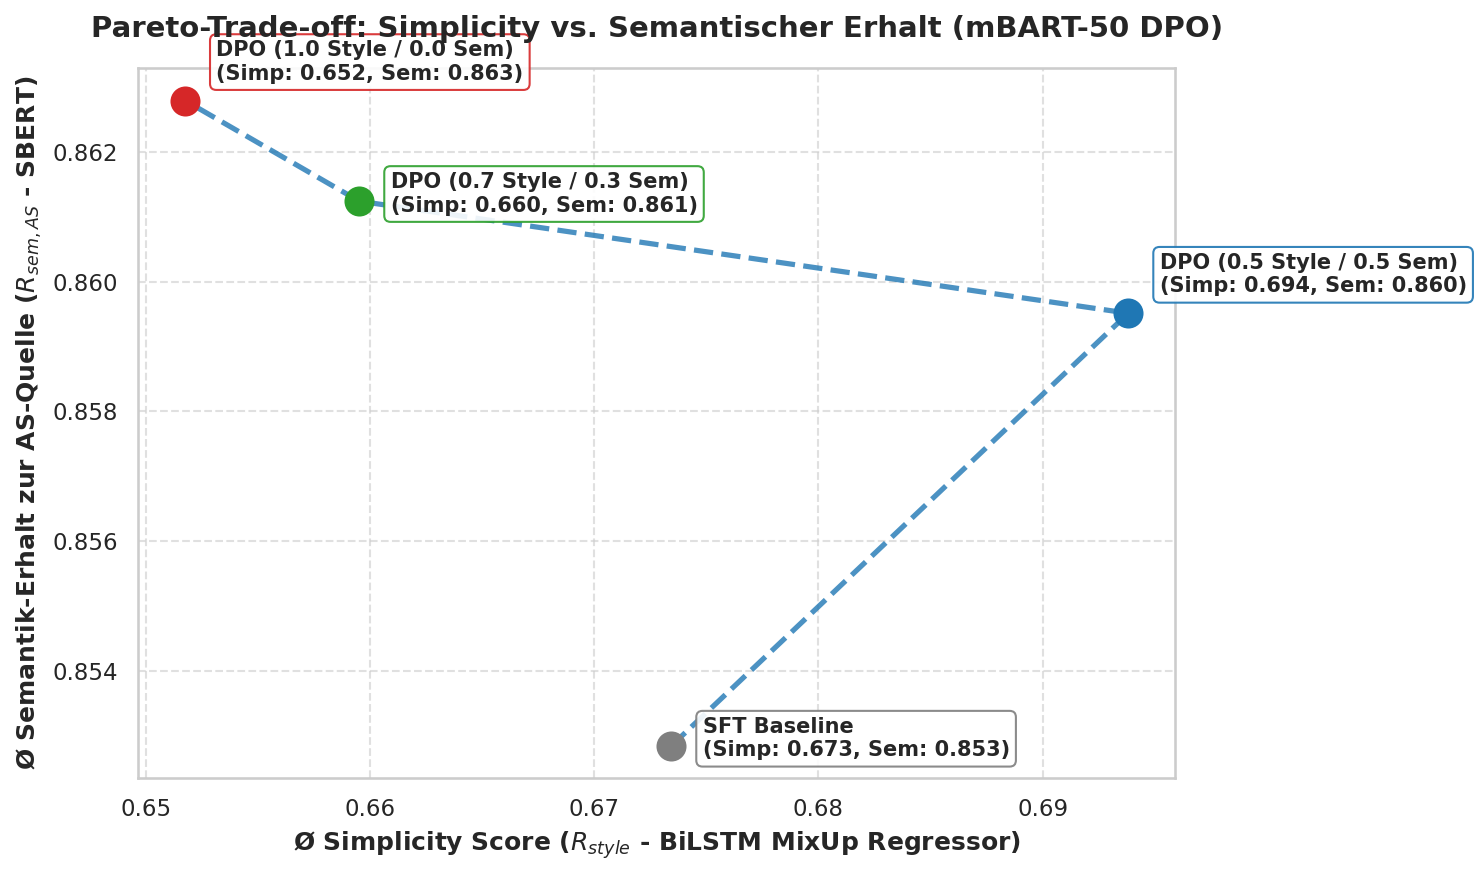

In [8]:
# ==============================================================================
# 8. PARETO-FRONTIER: SIMPLICITY VS. SEMANTIK-ERHALT
# ==============================================================================
if 'df_summary' in locals() and len(df_summary) > 0:
    simp_col = [c for c in df_summary.columns if "Simplicity" in c or "r_style" in c][0]
    sem_col = [c for c in df_summary.columns if "Semantik" in c or "r_sem" in c][0]
    name_col = [c for c in df_summary.columns if "Modell" in c or "model" in c][0]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_vals = df_summary[simp_col].astype(float)
    y_vals = df_summary[sem_col].astype(float)
    
    ax.plot(x_vals, y_vals, marker="o", markersize=12, linewidth=2.5, color="#1f77b4", linestyle="--", alpha=0.8, label="Trade-off Pfad")
    
    for i, row in df_summary.iterrows():
        m_name = row[name_col]
        x_pt = float(row[simp_col])
        y_pt = float(row[sem_col])
        color = MODELS_CONFIG.get(m_name, {}).get("color", "#333333")
        ax.scatter([x_pt], [y_pt], color=color, s=180, zorder=5)
        ax.annotate(
            f"{m_name}\n(Simp: {x_pt:.3f}, Sem: {y_pt:.3f})",
            (x_pt, y_pt),
            textcoords="offset points",
            xytext=(15, -5 if i % 2 == 0 else 10),
            fontweight="bold",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9)
        )
        
    ax.set_xlabel("Ø Simplicity Score ($R_{style}$ - BiLSTM MixUp Regressor)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Ø Semantik-Erhalt zur AS-Quelle ($R_{sem, AS}$ - SBERT)", fontsize=12, fontweight="bold")
    ax.set_title("Pareto-Trade-off: Simplicity vs. Semantischer Erhalt (mBART-50 DPO)", fontsize=14, fontweight="bold", pad=15)
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig("results/plots/pareto_frontier_metric_weights.png", dpi=300)
    plt.show()
else:
    print("Keine Daten fuer Trade-off-Kurve vorhanden.")

/tmp/ipykernel_1283054/234236364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_details, x="model_name", y="r_style", ax=axes[0], palette="Set2", showmeans=True)
/tmp/ipykernel_1283054/234236364.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_details, x="model_name", y="r_sem_as", ax=axes[1], palette="Set2", showmeans=True)


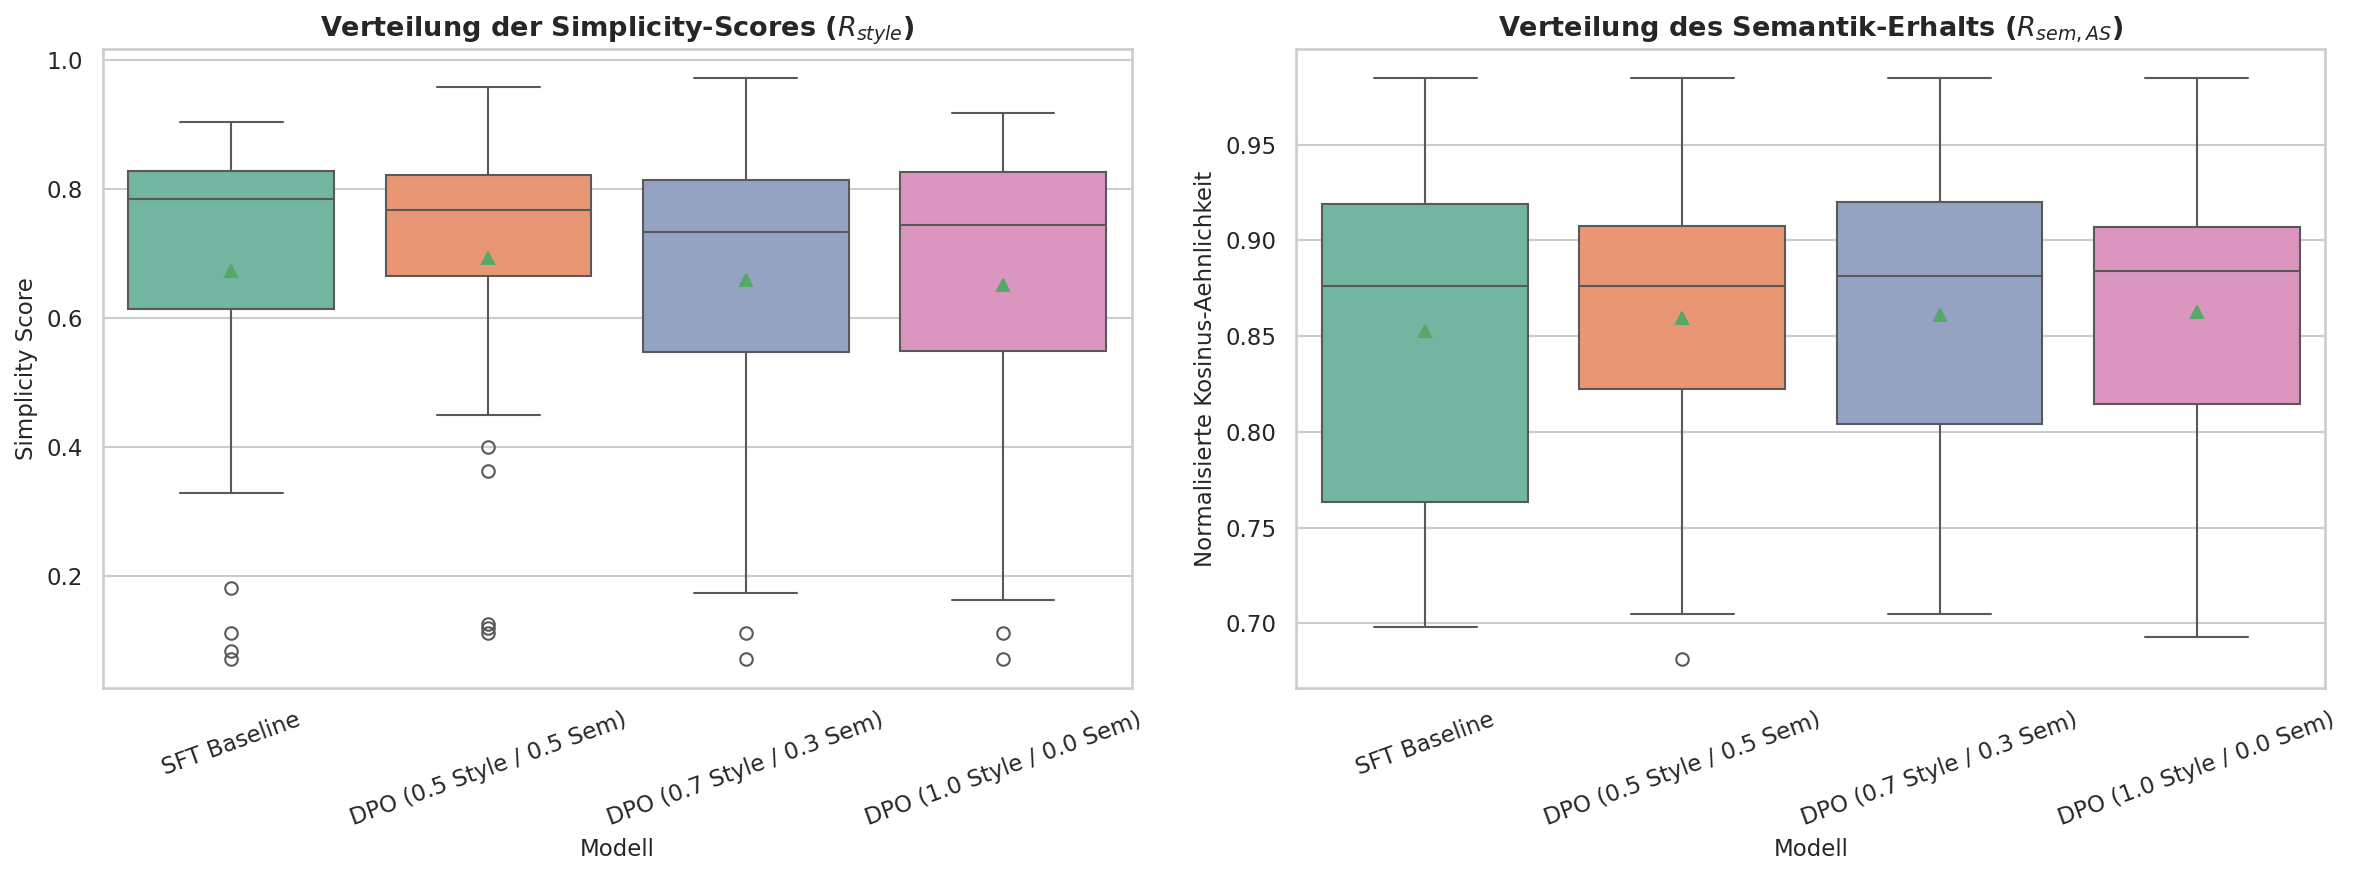

In [9]:
# ==============================================================================
# 9. SCORE-VERTEILUNGEN (BOXPLOTS & VIOLIN-PLOTS)
# ==============================================================================
if 'df_details' in locals() and len(df_details) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.boxplot(data=df_details, x="model_name", y="r_style", ax=axes[0], palette="Set2", showmeans=True)
    axes[0].set_title("Verteilung der Simplicity-Scores ($R_{style}$)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Modell", fontsize=11)
    axes[0].set_ylabel("Simplicity Score", fontsize=11)
    axes[0].tick_params(axis='x', rotation=20)
    
    sns.boxplot(data=df_details, x="model_name", y="r_sem_as", ax=axes[1], palette="Set2", showmeans=True)
    axes[1].set_title("Verteilung des Semantik-Erhalts ($R_{sem, AS}$)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Modell", fontsize=11)
    axes[1].set_ylabel("Normalisierte Kosinus-Aehnlichkeit", fontsize=11)
    axes[1].tick_params(axis='x', rotation=20)
    
    plt.tight_layout()
    plt.savefig("results/plots/score_distributions_metric_weights.png", dpi=300)
    plt.show()
else:
    print("Keine Detaildaten fuer Verteilungs-Plots vorhanden.")

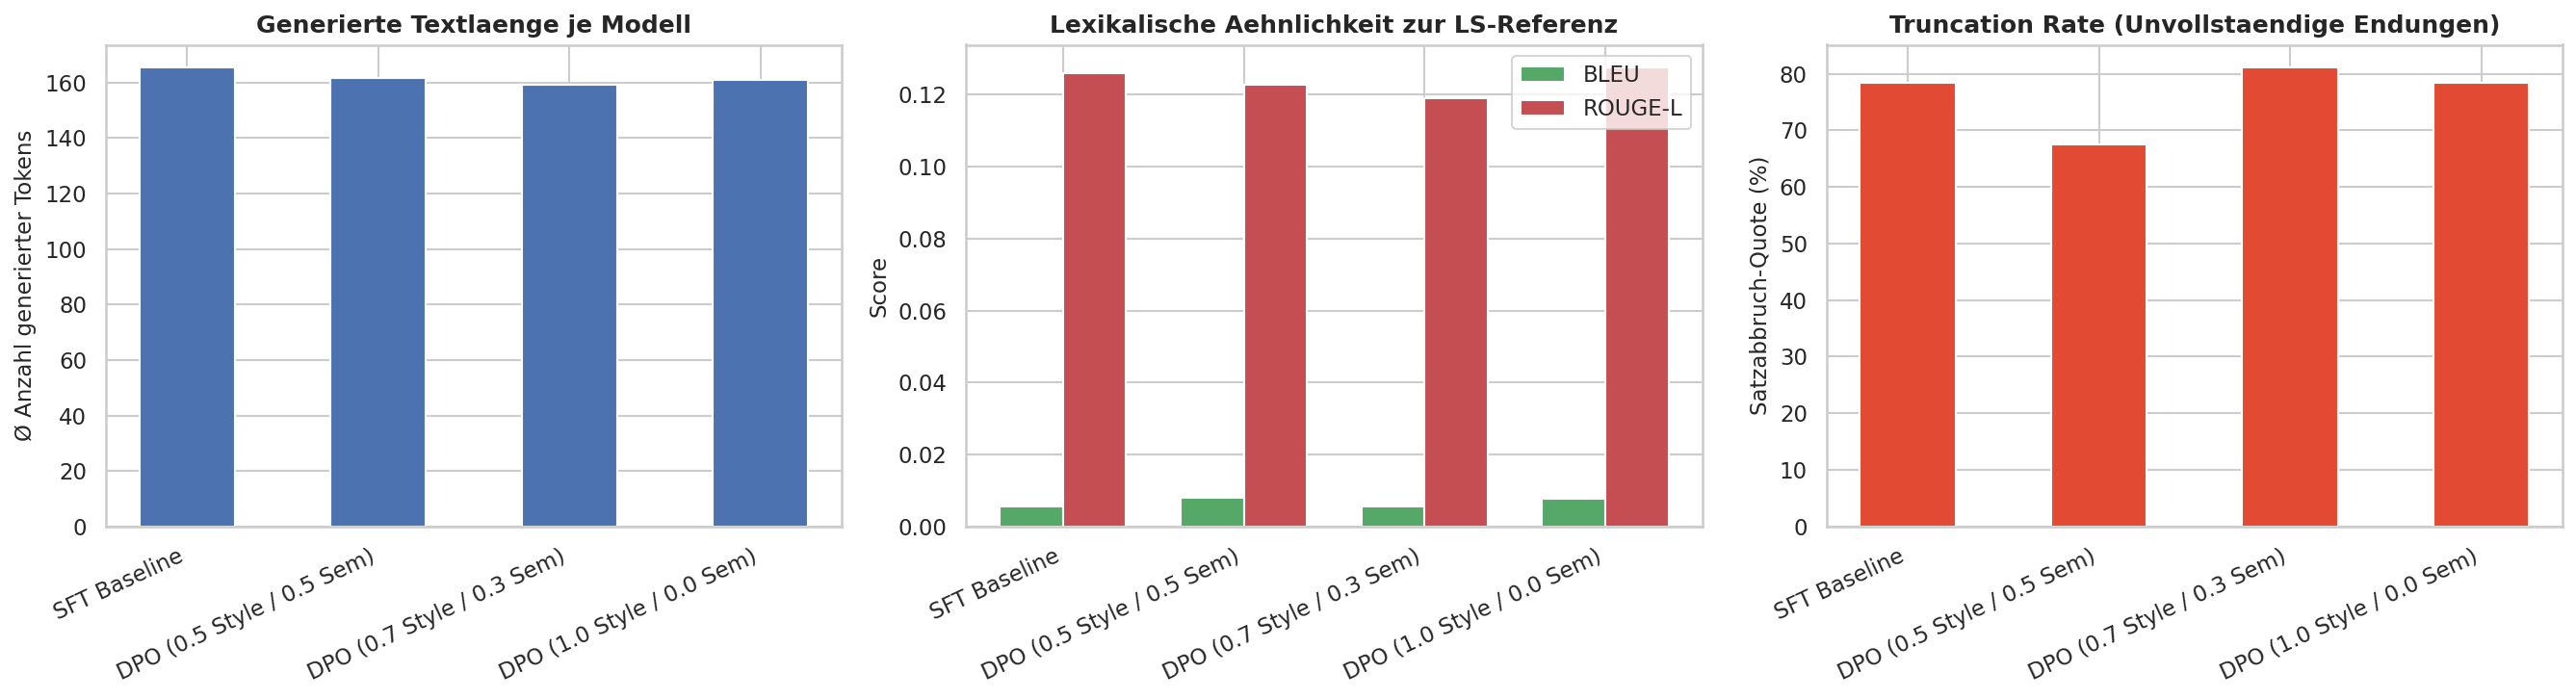

In [10]:
# ==============================================================================
# 10. TEXTLAENGE, KOMPRESSION & TRUNCATION RATE ANALYSE
# ==============================================================================
if 'df_summary' in locals() and len(df_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    name_col = [c for c in df_summary.columns if "Modell" in c or "model" in c][0]
    models = df_summary[name_col]
    x = np.arange(len(models))
    
    tok_col = [c for c in df_summary.columns if "Tokens" in c or "avg_gen_tokens" in c][0]
    axes[0].bar(x, df_summary[tok_col].astype(float), color="#4c72b0", width=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=25, ha="right")
    axes[0].set_ylabel("Ø Anzahl generierter Tokens", fontsize=11)
    axes[0].set_title("Generierte Textlaenge je Modell", fontsize=12, fontweight="bold")
    
    bleu_col = [c for c in df_summary.columns if "BLEU" in c][0]
    rouge_col = [c for c in df_summary.columns if "ROUGE" in c][0]
    w = 0.35
    axes[1].bar(x - w/2, df_summary[bleu_col].astype(float), width=w, label="BLEU", color="#55a868")
    axes[1].bar(x + w/2, df_summary[rouge_col].astype(float), width=w, label="ROUGE-L", color="#c44e52")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models, rotation=25, ha="right")
    axes[1].set_ylabel("Score", fontsize=11)
    axes[1].set_title("Lexikalische Aehnlichkeit zur LS-Referenz", fontsize=12, fontweight="bold")
    axes[1].legend()
    
    trunc_col = [c for c in df_summary.columns if "Truncation" in c][0]
    axes[2].bar(x, df_summary[trunc_col].astype(float), color="#e24a33", width=0.5)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(models, rotation=25, ha="right")
    axes[2].set_ylabel("Satzabbruch-Quote (%)", fontsize=11)
    axes[2].set_title("Truncation Rate (Unvollstaendige Endungen)", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("results/plots/length_and_truncation_metric_weights.png", dpi=300)
    plt.show()
else:
    print("Keine Laengendaten verfuegbar.")

## 7. Qualitativer Side-by-Side Modellvergleich (Beispielsätze)

In [11]:
# ==============================================================================
# 11. QUALITATIVES AUDIT: STICHPROBEN IM DETAIL
# ==============================================================================
if 'df_details' in locals() and len(df_details) > 0:
    sample_queries = df_details["as_text"].unique()[:5]
    
    for idx, as_s in enumerate(sample_queries, 1):
        sub_df = df_details[df_details["as_text"] == as_s]
        ls_ref = sub_df["ls_ref_text"].iloc[0]
        
        print(f"\n{'#'*90}")
        print(f"BEISPIEL {idx}:")
        print(f"[AS Quelle] : {as_s}")
        print(f"[LS Referenz]: {ls_ref}")
        print(f"{'-'*90}")
        
        for _, r in sub_df.iterrows():
            print(f"[{r['model_name']:28s}] (Simp: {r['r_style']:.3f} | Sem-AS: {r['r_sem_as']:.3f} | Tokens: {r['gen_tokens']}):")
            print(f"  {r['generated_text']}\n")
else:
    print("Keine Detail-Uebersetzungen verfuegbar.")


##########################################################################################
BEISPIEL 1:
[AS Quelle] : Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf dieser Basis ein selbstfinanziertes Leben führen zu können. Das bedeutet, dass die Menschen grundsätzlich Grundsicherung beantragen müssen, um ihren Lebensunterhalt zu bestreiten – es sei denn, sie erhalten bereits eine Erwerbsminderungsrente und können in der Werkstatt noch so viel dazu verdienen, dass es gerade zum Leben reicht. Die Pandemie-bedingten Betretungsverbote für die WfbMs und die damit aller Orten eingebrochenen Erträge machen die Auszahlung dieser Löhne nun aber auch immer schwieriger

## 8. Interaktiver Übersetzungs-Playground

In [12]:
# ==============================================================================
# 12. INTERAKTIVE LIVE-UEBERSETZUNG (EIGENER SATZ)
# ==============================================================================
def translate_custom_sentence(sentence: str):
    print(f"\n{'='*80}")
    print(f"Eingegebener Quelltext (AS):\n'{sentence}'")
    print(f"{'='*80}")
    
    for model_name, model_info in MODELS_CONFIG.items():
        m_path = model_info["path"]
        if not os.path.exists(m_path):
            continue
            
        tok_path = m_path if os.path.exists(os.path.join(m_path, "tokenizer_config.json")) else BASE_MODEL_NAME
        tokenizer = AutoTokenizer.from_pretrained(tok_path, use_fast=False)
        tokenizer.src_lang = "de_DE"
        tokenizer.tgt_lang = "de_DE"
        
        model = load_seq2seq_model(m_path, BASE_MODEL_NAME)
        model.eval()
        
        inputs = tokenizer([sentence], max_length=MAX_SOURCE_LEN, padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = model.generate(inputs["input_ids"], max_length=MAX_TARGET_LEN, num_beams=4, no_repeat_ngram_size=3)
        trans = tokenizer.decode(out[0], skip_special_tokens=True)
        
        simp = float(compute_simplicity_scores([trans])[0])
        sem = float(np.clip((compute_semantic_similarity([sentence], [trans])[0] + 1.0) / 2.0, 0.0, 1.0))
        
        print(f"\n[{model_name}] (Simplicity: {simp:.3f}, Semantik: {sem:.3f}):")
        print(f"  {trans}")
        
        del model
        torch.cuda.empty_cache()

# Teste einen komplexen Beispielsatz:
test_input = "Aufgrund der anhaltenden Bauarbeiten an den Gleisanlagen kommt es auf der Strecke zwischen Hamburg und Hannover zu erheblichen Verzoegerungen im Regional- und Fernverkehr."
translate_custom_sentence(test_input)


Eingegebener Quelltext (AS):
'Aufgrund der anhaltenden Bauarbeiten an den Gleisanlagen kommt es auf der Strecke zwischen Hamburg und Hannover zu erheblichen Verzoegerungen im Regional- und Fernverkehr.'
[MODELL-LADEN] results/models/sft
  -> Lade-Modus: Vollstaendig fusioniertes Modell (model.safetensors, 2331.3 MB)
  -> Instanziierte Modell-Klasse: MBartForConditionalGeneration (torch.float16)


[SFT Baseline] (Simplicity: 0.373, Semantik: 0.904):
  Was passiert auf der Strecke zwischen Hamburg und Hannover?
[MODELL-LADEN] results/models/metric_weights_exp/dpo_w05_w05
  -> Lade-Modus: Vollstaendig fusioniertes Modell (model.safetensors, 1165.7 MB)
  -> Instanziierte Modell-Klasse: MBartForConditionalGeneration (torch.float16)


[DPO (0.5 Style / 0.5 Sem)] (Simplicity: 0.373, Semantik: 0.904):
  Was passiert auf der Strecke zwischen Hamburg und Hannover?
[MODELL-LADEN] results/models/metric_weights_exp/dpo_w07_w03
  -> Lade-Modus: Vollstaendig fusioniertes Modell (model.safetensors, 1